In [1]:
%pip install -q pandas numpy seaborn matplotlib scipy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
sns.set_style("whitegrid")
pd.set_option("display.max_columns",40)

### Load Datasets

In [3]:
titanic=sns.load_dataset("titanic")

In [4]:
df=titanic

2. Numerical vs Numerical

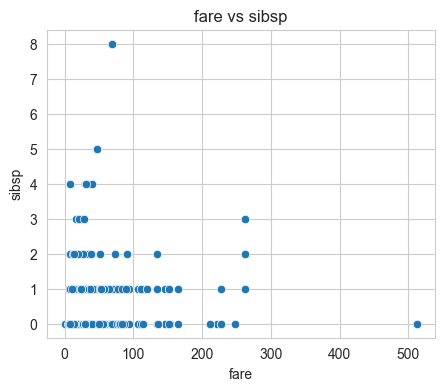

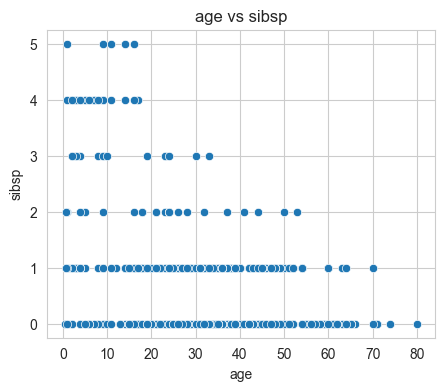

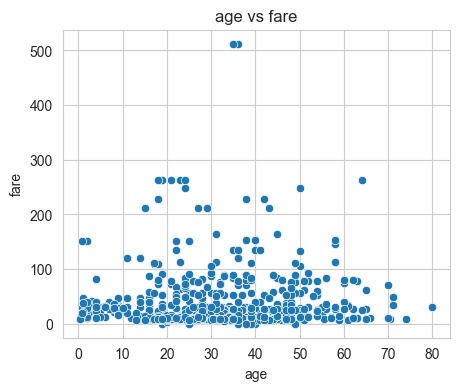

In [5]:
num_pairs={
    ("age","fare"),
    ("age","sibsp"),
    ("fare","sibsp")
}
for x,y in num_pairs:
    plt.figure(figsize=(5,4))
    sns.scatterplot(x=df[x],y=df[y])
    plt.title(f"{x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show() 

3.2 correlation Matrix

In [6]:
nums_cols=["age","fare","sibsp","parch"]


In [7]:
df_num=df[nums_cols].dropna()

In [8]:
print("correlation matrix:")
df_num.corr()
#-1 represent high negative correlation
# 1 represent high positive correlation

correlation matrix:


,age,fare,sibsp,parch
age,1.000000,0.096067,-0.308247,-0.189119
fare,0.096067,1.000000,0.138329,0.205119
sibsp,-0.308247,0.138329,1.000000,0.383820
parch,-0.189119,0.205119,0.383820,1.000000


In [9]:
num_pairs={
    ("age","fare"),
    ("age","sibsp"),
    ("fare","sibsp")
}

In [10]:
print("Personr correlation with fare:")
for col in nums_cols :
    if col!="fare":
        r,p=pearsonr(df_num[col],df_num["fare"])
        print(f"{col} vs fare:r= {r:.3f}: p={p:.3f}")

Personr correlation with fare:
age vs fare:r= 0.096: p=0.010
sibsp vs fare:r= 0.138: p=0.000
parch vs fare:r= 0.205: p=0.000


4. Numerical vs Categorical

boxplot


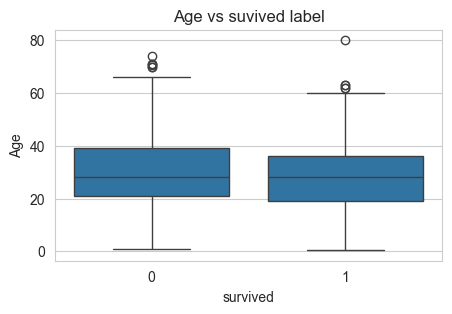

In [11]:
plt.figure(figsize=(5,3))
sns.boxplot(x=df["survived"],y=df["age"])
plt.xlabel("survived")
plt.ylabel("Age")
plt.title("Age vs suvived label")
plt.show()

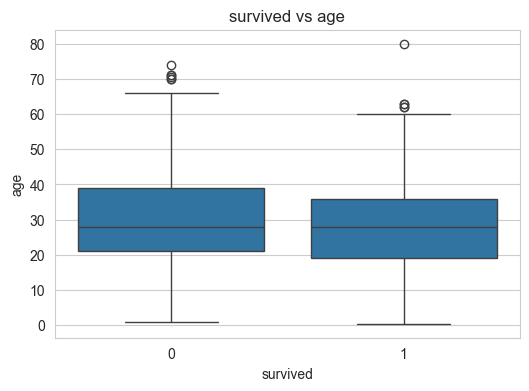

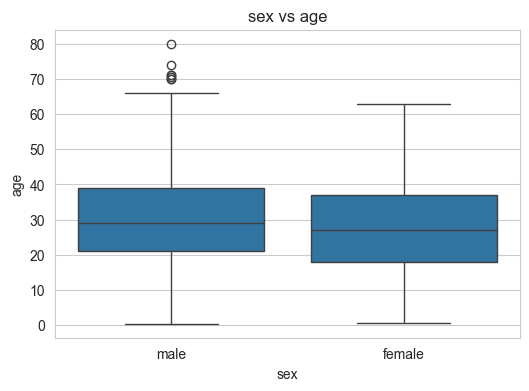

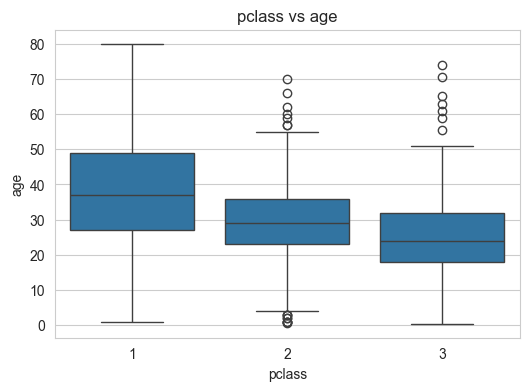

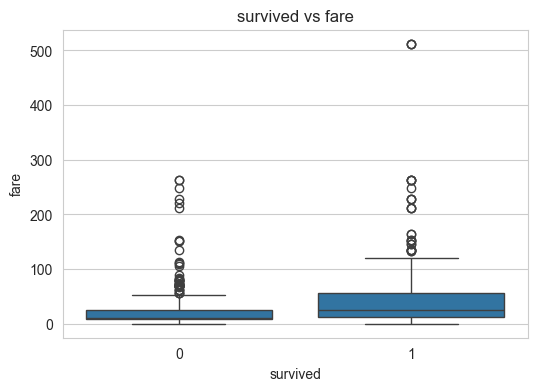

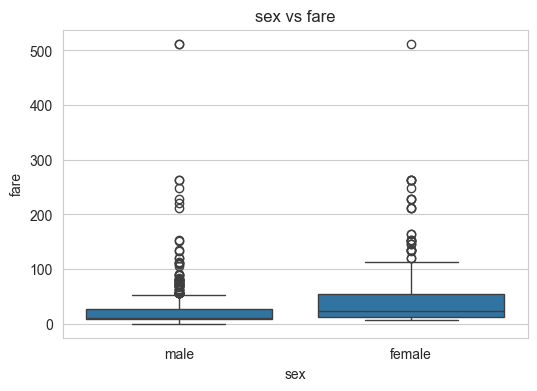

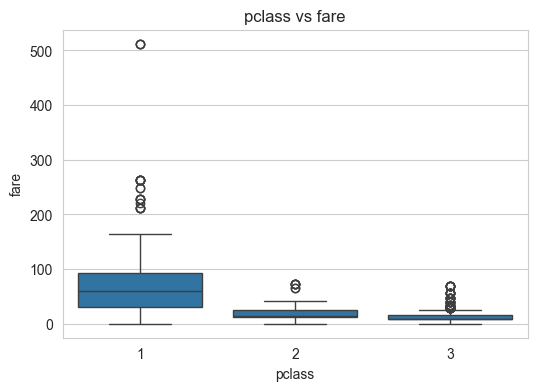

In [12]:
num_for_box=["age","fare"]
cat_for_box=["survived","sex","pclass"]
for num in num_for_box:
    for cat in cat_for_box:
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[cat],y=df[num])
        plt.title(f"{cat} vs {num}")
        plt.xlabel(cat)
        plt.ylabel(num)
        plt.show()

grouped statatics


In [13]:
df["survived_label"]=df["survived"].map({0:"NO",1:"yes"})

In [14]:
df[nums_cols+["survived_label"]].groupby("survived_label").mean()

,age,fare,sibsp,parch
survived_label,,,,
NO,30.626179,22.117887,0.553734,0.329690
yes,28.343690,48.395408,0.473684,0.464912


In [15]:
df[nums_cols].groupby("age").mean()


,fare,sibsp,parch
age,,,
0.42,8.5167,0.0,1.0
0.67,14.5000,1.0,1.0
0.75,19.2583,2.0,1.0
0.83,23.8750,0.5,1.5
0.92,151.5500,1.0,2.0
...,...,...,...
70.00,40.7500,0.5,0.5
70.50,7.7500,0.0,0.0
71.00,42.0792,0.0,0.0


In [16]:
for cat in ["survived_label","sex","pclass"]:
    print(f"Grouped by {cat}")
    print(df.groupby(cat)["fare"].describe())
    print("-"*50)

Grouped by survived_label
                count       mean        std  min      25%   50%   75%  \
survived_label                                                          
NO              549.0  22.117887  31.388207  0.0   7.8542  10.5  26.0   
yes             342.0  48.395408  66.596998  0.0  12.4750  26.0  57.0   

                     max  
survived_label            
NO              263.0000  
yes             512.3292  
--------------------------------------------------
Grouped by sex
        count       mean        std   min        25%   50%    75%       max
sex                                                                        
female  314.0  44.479818  57.997698  6.75  12.071875  23.0  55.00  512.3292
male    577.0  25.523893  43.138263  0.00   7.895800  10.5  26.55  512.3292
--------------------------------------------------
Grouped by pclass
        count       mean        std  min       25%      50%   75%       max
pclass                                                    

Categorical vs Categorical

In [17]:
print("Crosstab : sex vs survived:")
print(pd.crosstab(df["pclass"],df["survived_label"]))

Crosstab : sex vs survived:
survived_label   NO  yes
pclass                  
1                80  136
2                97   87
3               372  119


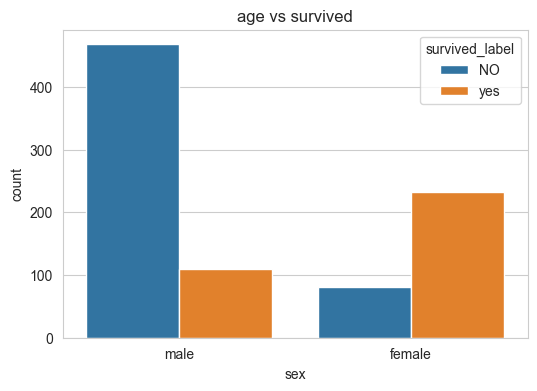

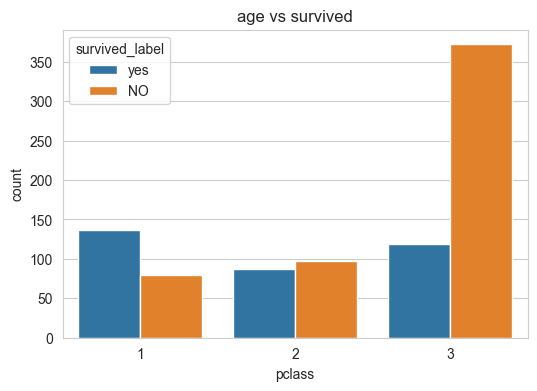

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["sex"],hue=df["survived_label"])
plt.title("age vs survived")
plt.show()



plt.figure(figsize=(6,4))
sns.countplot(x=df["pclass"],hue=df["survived_label"])
plt.title("age vs survived")
plt.show()

# <b>Multivariate Analysis<b>

- Pairplot
- correlation 
- Heatmap
- heat Map
- Cluster map
- interaction and sub group pattern

- pairplot

In [19]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,survived_label
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,NO
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,yes
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,yes
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,yes
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,NO


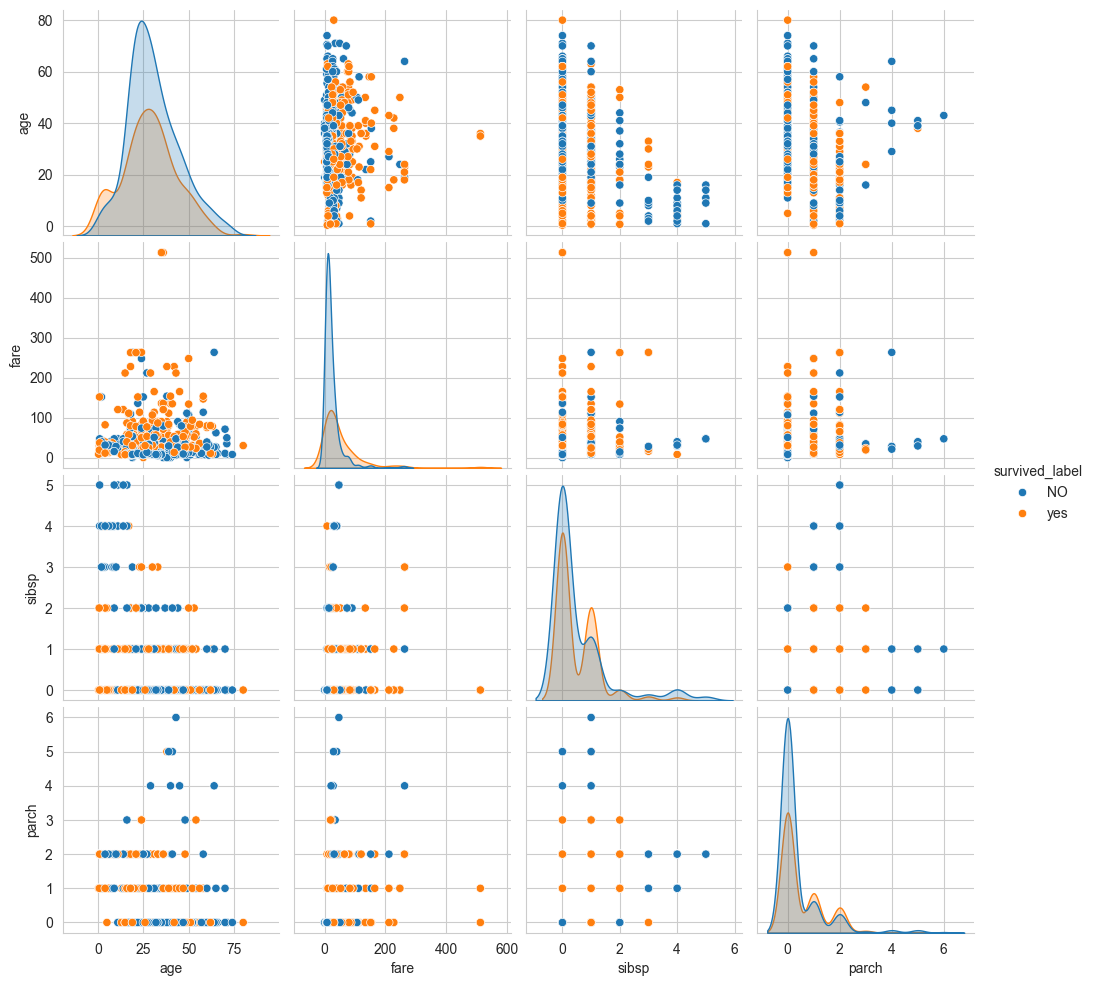

In [23]:
pairplot_cols=nums_cols+["survived_label"]
df_pair=df[pairplot_cols].dropna()
sns.pairplot(df_pair,hue="survived_label")
plt.show()


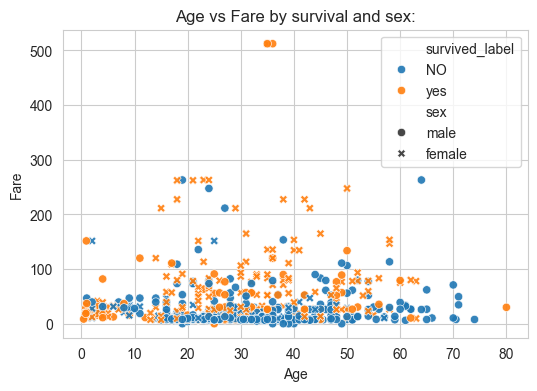

In [24]:
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="age",
    y='fare',
    hue="survived_label",
    style='sex',
    alpha=0.9
)
plt.title("Age vs Fare by survival and sex:")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

- correlation heatmap


In [26]:
df_num.head()

,age,fare,sibsp,parch
0,22.0,7.2500,1,0
1,38.0,71.2833,1,0
2,26.0,7.9250,0,0
3,35.0,53.1000,1,0
4,35.0,8.0500,0,0


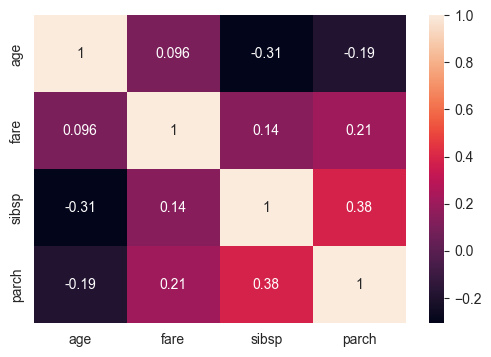

In [27]:
plt.figure(figsize=(6,4))
sns.heatmap(df_num.corr(),annot=True)
plt.title=("correlation of numerical features onlhy")
plt.show()

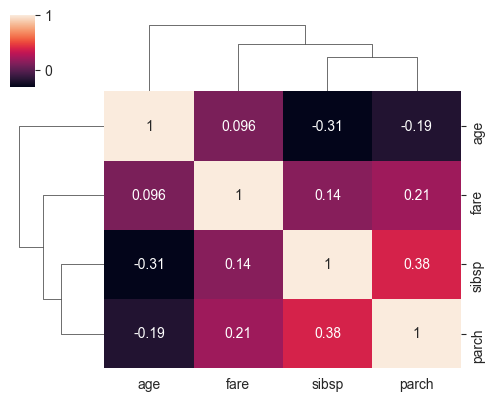

In [29]:
sns.clustermap(df_num.corr(),annot=True,figsize=(5,4))
plt.show()

- - Interaction and sub group plattern discovery

TypeError: 'str' object is not callable

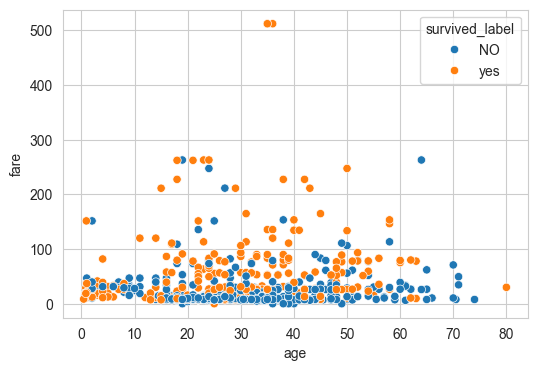

In [35]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age"],y=df["fare"],hue=df["survived_label"])
plt.title("Age vs fare")

plt.show()

- sub groups: sibling/spouse

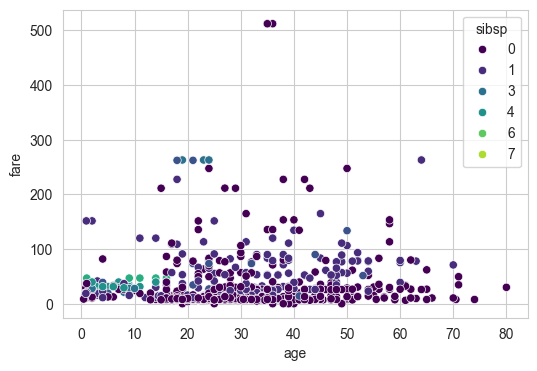

In [50]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["age"],y=df["fare"],hue=df["sibsp"],palette="viridis")
plt.show()